# EE / CprE / CybE 3250: Machine Learning for Electrical, Computer, and Cybersecurity Engineering
## Lab-04: Multilayer and Convolutional Neural Networks
> *[Note from your instructor: In this lab, you will develop and train more advanced models. You will gain experience introducing nonlinearity into networks and explore the functions used to achieve it. You will also be introduced to convolutions and their key parameters, and build toward modern image classification approaches using convolutional neural networks (CNNs). You will also explore additional techniques that improve model performance and generalization, such as dropout for regularization, pooling layers for dimensionality reduction, and other architectural enhancements commonly used in modern neural networks. As before, collaboration is encouraged, as is the use of generative AI for debugging and coding support. However, all conceptual answers must be your own work. You will be evaluated based on lab preparation (PreLab), responses to programming and conceptual questions (Lab), and demonstration of understanding (PostLab).]*

**Names:** 

**Group Name:**



### 0. Prelab
Please read through this entire document and answer the questions at the end under the “Prelab Questions” section header. These are due and will be checked at the beginning of the lab – please post if you have any questions.


In [1]:
# Initial setup
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from d2l import torch as d2l

### 1. A More Complex Image Dataset

In Lab-03, we were able to achieve a reasonably high classification accuracy on the MNIST handwriting recognition dataset using a relatively simple softmax regression model. But what happens when we consider more complex image datasets? As part of our journey of exploring more complex networks, we next turn to the [CIFAR-10](https://cave.cs.toronto.edu/kriz/cifar.html) image dataset. We can access it using the torchvision library as before:

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

cifar10_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
cifar10_val = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

100%|██████████| 170M/170M [00:27<00:00, 6.23MB/s] 


- **Q1.1:** In the code block below, explore both the training and validation sets of the CIFAR-10 dataset. Just like with the MNIST dataset, when using a torchvision dataset you can use the `.data` and `.targets` attributes to access the data arrays and labels. What are some ways in which this data is similar to what we previously worked with (how is it similar in nature to MNIST)? In what ways is it different? What makes it "more complex"? Be specific. 

- **A1.1:** This is similar as it is images (obviously) but not they contain color and are effectively downsampled versions of images until they are 32 x 32 x 3. This means that the images are 32x32 instead of 28x28 and the last dimension (which before was pixel intensity) are now color channels! The dataset is large at 50,000 training images and 10,000 validation images.

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
[[[[ 59  62  63]
   [ 43  46  45]
   [ 50  48  43]
   ...
   [158 132 108]
   [152 125 102]
   [148 124 103]]

  [[ 16  20  20]
   [  0   0   0]
   [ 18   8   0]
   ...
   [123  88  55]
   [119  83  50]
   [122  87  57]]

  [[ 25  24  21]
   [ 16   7   0]
   [ 49  27   8]
   ...
   [118  84  50]
   [120  84  50]
   [109  73  42]]

  ...

  [[208 170  96]
   [201 153  34]
   [198 161  26]
   ...
   [160 133  70]
   [ 56  31   7]
   [ 53  34  20]]

  [[180 139  96]
   [173 123  42]
   [186 144  30]
   ...
   [184 148  94]
   [ 97  62  34]
   [ 83  53  34]]

  [[177 144 116]
   [168 129  94]
   [179 142  87]
   ...
   [216 184 140]
   [151 118  84]
   [123  92  72]]]


 [[[154 177 187]
   [126 137 136]
   [105 104  95]
   ...
   [ 91  95  71]
   [ 87  90  71]
   [ 79  81  70]]

  [[140 160 169]
   [145 153 154]
   [125 125 118]
   ...
   [ 96  99  78]
   [ 77  80  62]
   [ 71  73  61]]

  [[140 155 

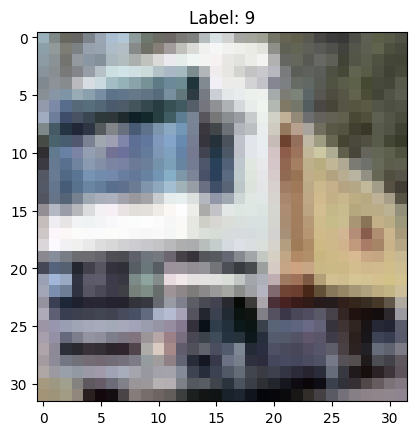

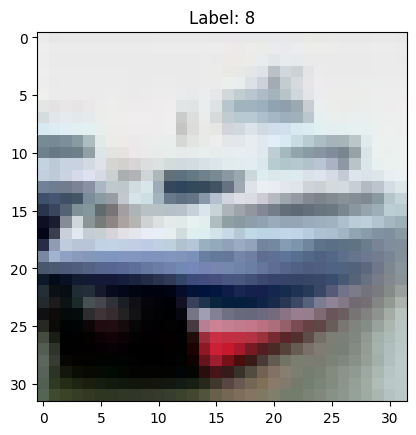

In [11]:
print(cifar10_train)

# YOUR CODE STARTS HERE
print(cifar10_train.data)
print(cifar10_train.data.shape)
print(f"train shape: {cifar10_train.targets}")



print(f"val shape: {cifar10_val.data.shape}")
print(cifar10_val.targets)
plt.imshow(cifar10_train.data[1])
plt.title(f"Label: {cifar10_train.targets[1]}")
plt.show()
plt.imshow(cifar10_val.data[1])
plt.title(f"Label: {cifar10_val.targets[1]}")
plt.show()
# YOUR CODE ENDS HERE


Unlike our MNIST dataset, where each label inherently corresponds to the digit represented in each image, for CIFAR-10, there are 10 classes of images: "airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", and "truck". Let's encode these directly as a list of text labels that we can refer to when processing images later:

In [12]:
cifar10_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
cifar10_label_map = {i: name for i, name in enumerate(cifar10_labels)}

Like we did with MNIST, let's quickly check that the classes are roughly balanced via plotting a bar chart of the labels in our training set. There are numerous ways we can accomplish this - here, we convert to a Pandas dataframe for quick counting:

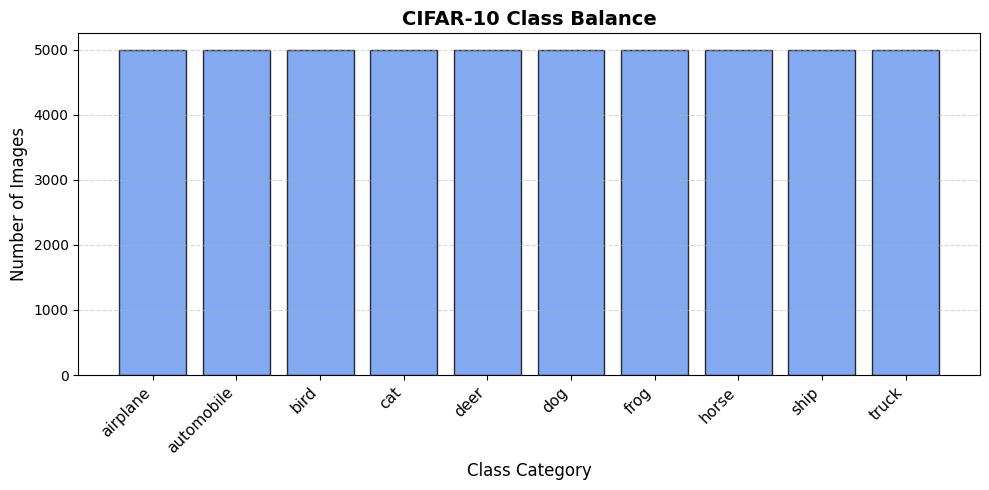

In [13]:
# Count the frequencies for each label
cifar10_label_series = pd.Series(cifar10_train.targets)
class_counts = cifar10_label_series.value_counts().sort_index()

# Map the numeric IDs to names
tick_labels = [cifar10_label_map[i] for i in class_counts.index]

# Build the bar chart visualization
plt.figure(figsize=(10, 5))
plt.bar(tick_labels, class_counts.values, color='cornflowerblue', edgecolor='black', alpha=0.8)

# Formatting to avoid overlapping labels
plt.title("CIFAR-10 Class Balance", fontsize=14, fontweight='bold')
plt.xlabel("Class Category", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)  # Rotate to prevent overlapping text
plt.grid(axis='y', linestyle='--', alpha=0.5)     # Add light gridlines for scale readability

# Adjust layout so labels aren't truncated
plt.tight_layout()
plt.show()

Not coincidentally, the class distribution of CIFAR-10 is perfectly uniform. Next, let's view a sample of these images. The CIFAR website provides a nice visualization of 10 random images from each class. Below, complete the code to replicate that visualization:


0 airplane
[11240 22796  5973 10578 41741 48096 43564 37078  2451 35263]
1 automobile
[35058  9247  7738 39532 32488 37354 29230 19363  2289 45434]
2 bird
[21867 20859 11641 26265 47142 47281   538 28333  2927 42639]
3 cat
[33133 30886 13313  5445  6567 13941 39220 35581 27906 17530]
4 deer
[45132  5631  6292 21052  6021 21222 23739 36572 43224 11927]
5 dog
[36471 37815 13598 47954 37099 29358 24243 44211 26281 17527]
6 frog
[12066  7481 24626  6859 49171 45165 42509   929  5182 26340]
7 horse
[11446  2201 35003 26779 34719 24416 26208 40439 28201 30984]
8 ship
[38453 17281 29317 44811 32271 14728  9861 39106 12806 35766]
9 truck
[29507 18898     1 49546 41329 28774 19073 33676   495 19674]


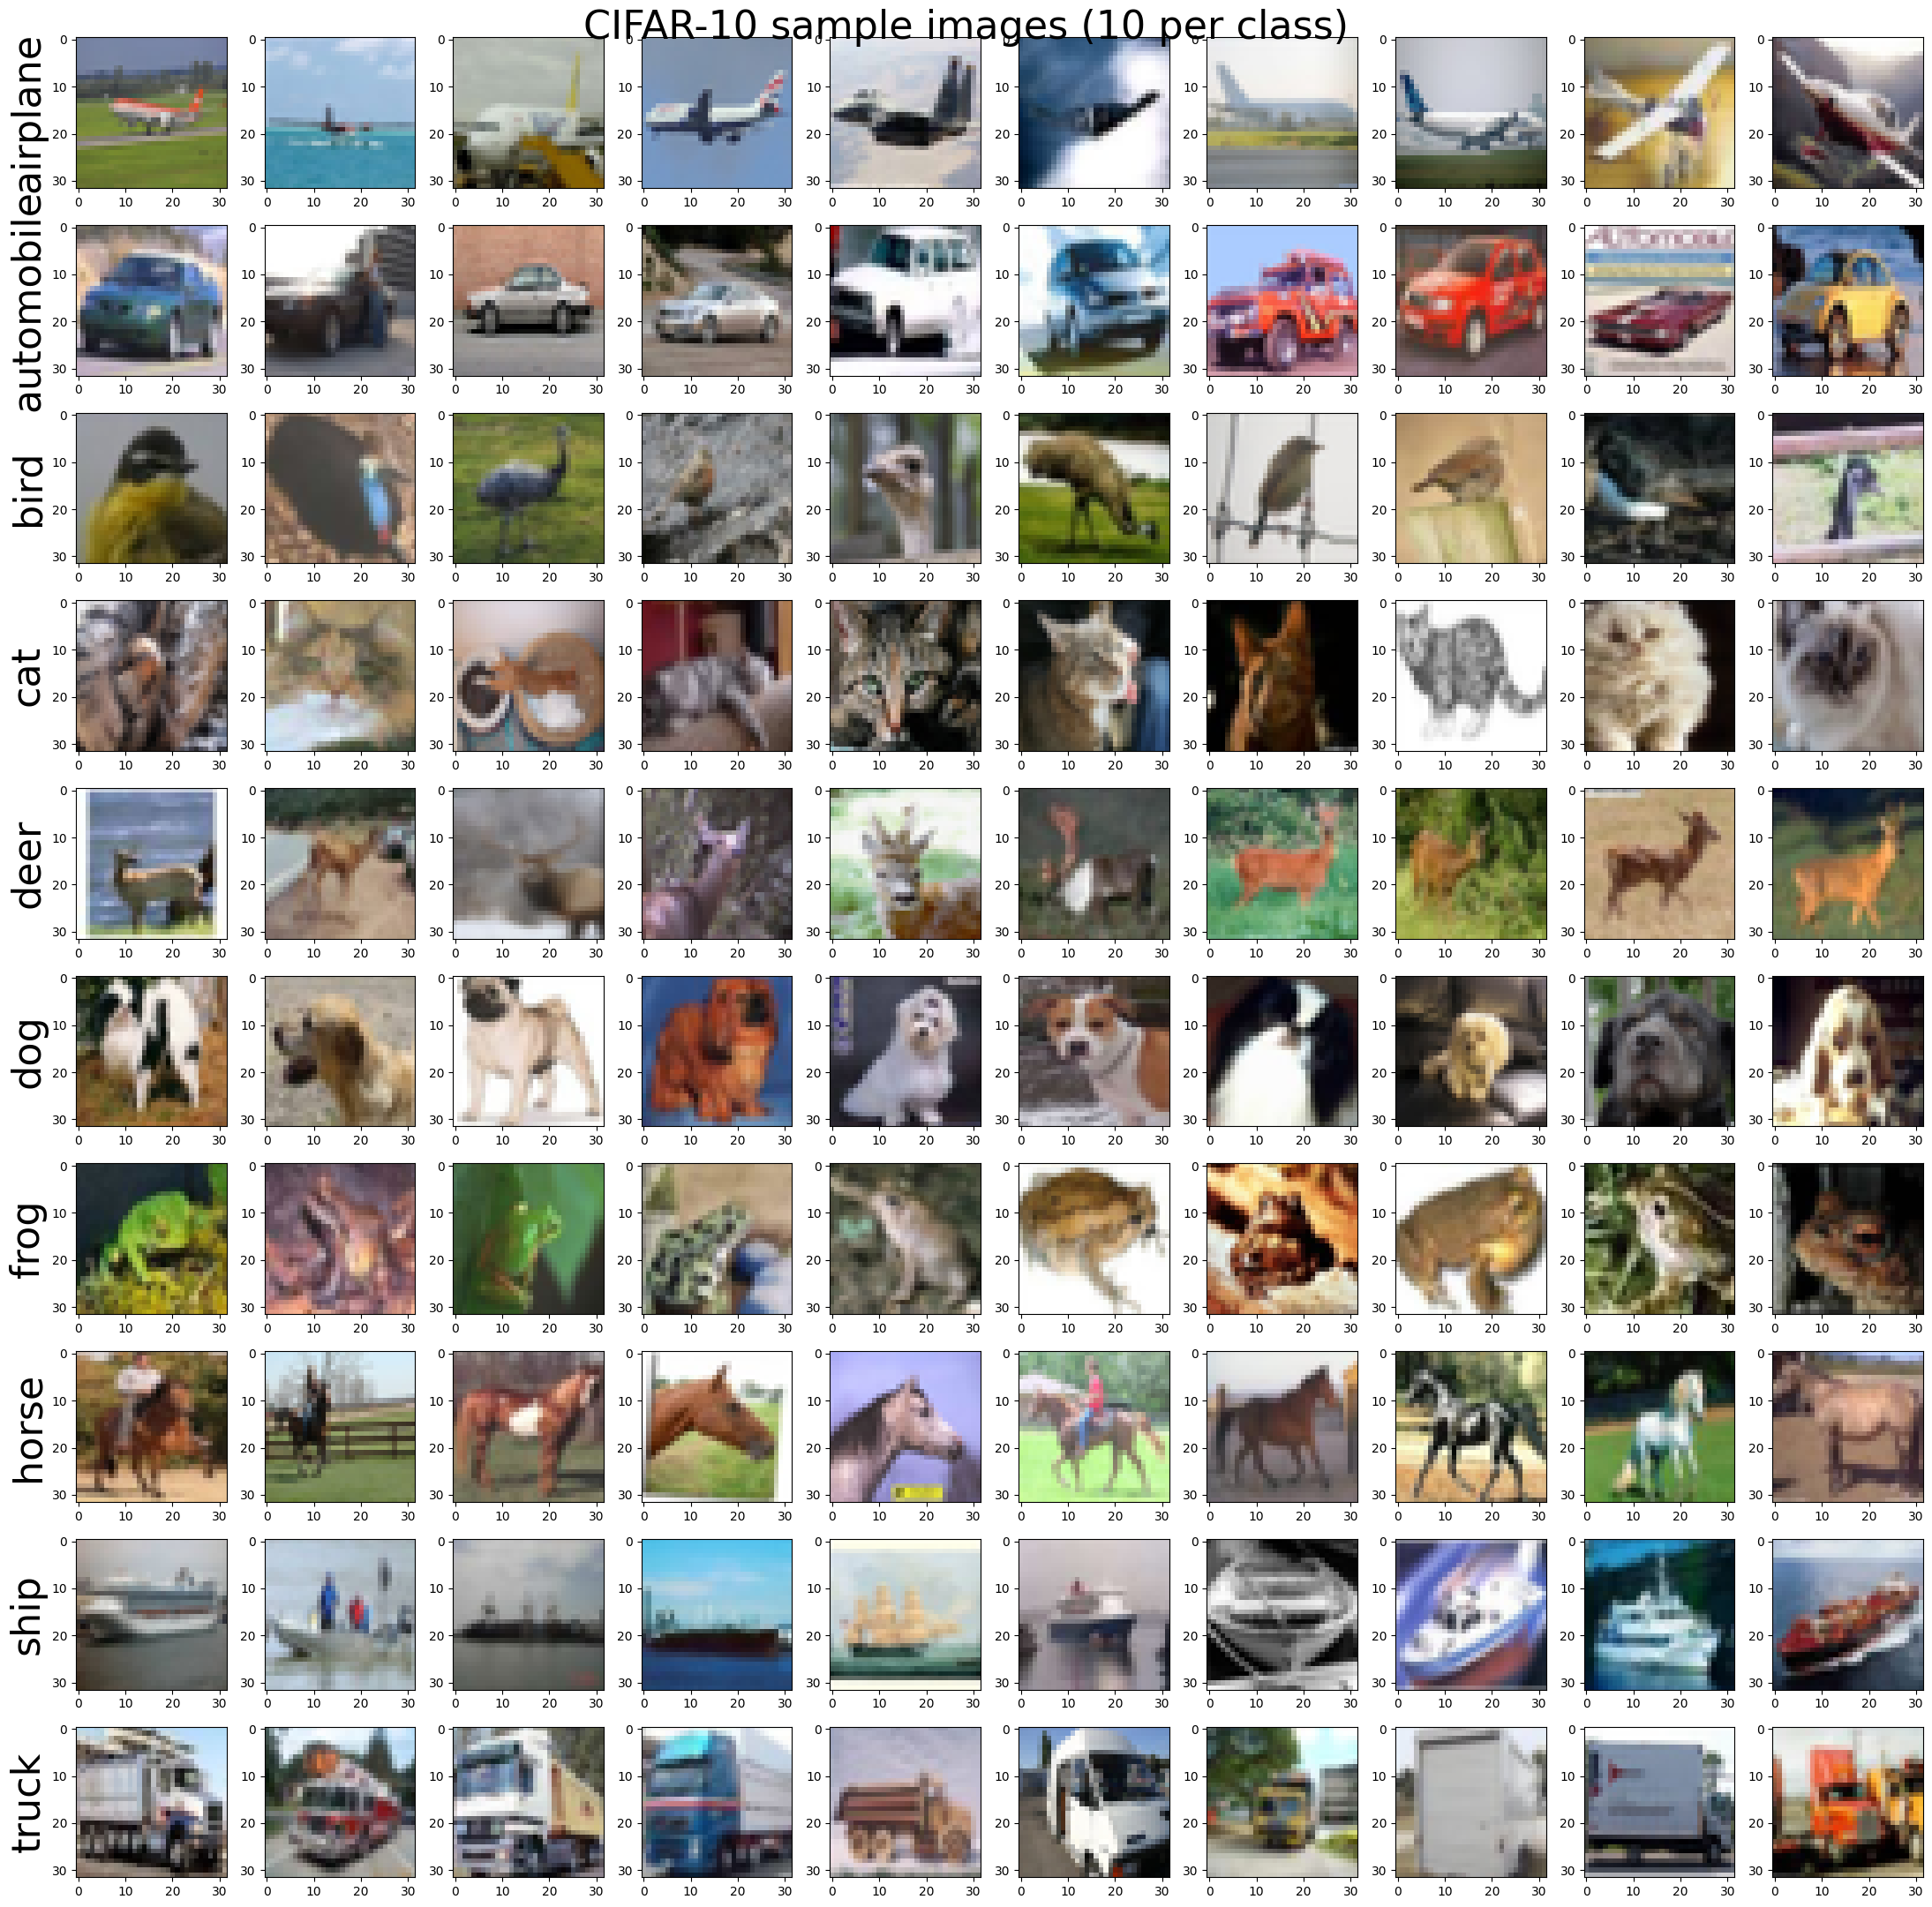

In [26]:

targets = np.array(cifar10_train.targets)
images = np.array(cifar10_train.data)

fig, axes = plt.subplots(10, 10, figsize=(22, 22))
fig.suptitle("CIFAR-10 sample images (10 per class)", fontsize=32)

for row, class_name in enumerate(cifar10_labels):

    print(row, class_name)

    # Pick 10 random indices for this class
    class_idx = np.where(targets == row)[0]
    sample_idx = np.random.choice(class_idx, size=10, replace=False)

    print(sample_idx)

# YOUR CODE STARTS HERE
    for col in range(10):
        ax = axes[row, col]
        ax.imshow(images[sample_idx[col]])


# YOUR CODE ENDS HERE

    axes[row, 0].set_ylabel(class_name, fontsize=32)

plt.tight_layout()
plt.show()

One visually compelling thing we can do to gain some insight into the features of our image set is to compute the "average image" for each class. We can use similar code as before to find the indices that match each label / class and calculate the means. Then, for each class we plot its collection of average pixels. This will show us the spatial pixel color trends associated with each image, and help us to understand how our model will determine patterns to classify images. 

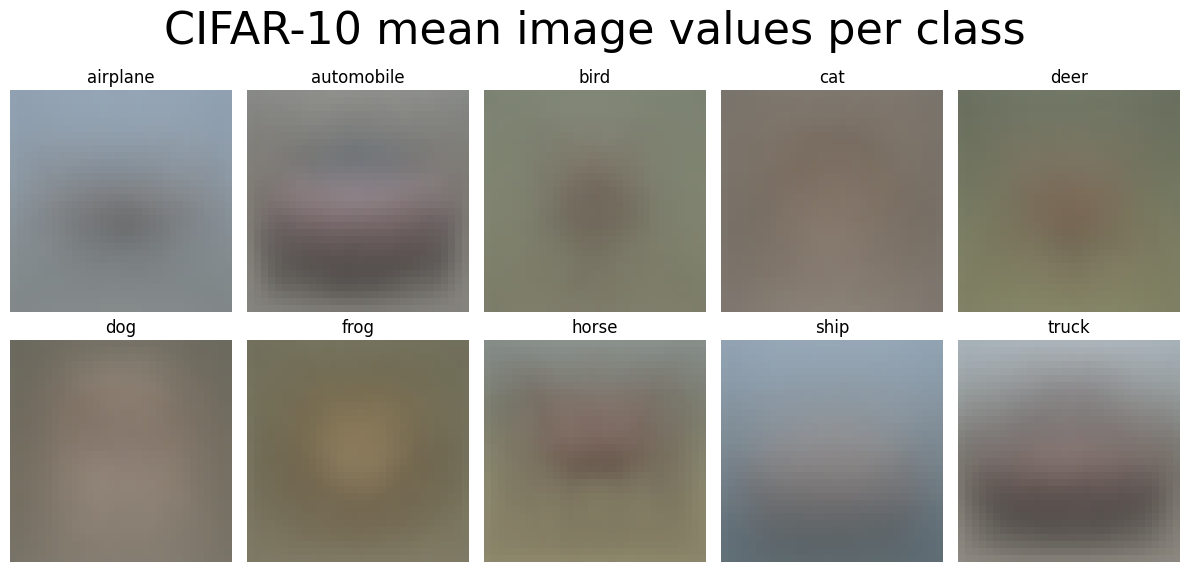

In [27]:
targets = np.array(cifar10_train.targets)
images = np.array(cifar10_train.data)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()
fig.suptitle("CIFAR-10 mean image values per class", fontsize=32)

for i, class_name in enumerate(cifar10_labels):
    class_idx = np.where(targets == i)[0]
    avg_image = np.mean(images[class_idx], axis=0)
    
    axes[i].imshow(avg_image.astype('uint8'))
    axes[i].set_title(class_name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

- **Q1.2):** Based off of the mean image values per class, are there some classes a model may struggle to differentiate between? Give some examples of classes with similar patterns. Begin hypothesizing; how could our model still have success when some classes have such similar patterns?

- **A1.2):** It might struggle against deer and horse, as they share a similar background and general shape. While from the mean image ship and airplane look the same (blue background) the model would probably still succeed because the individual ship and airplane are likely much different.

Let's construct our D2L dataloader class for this dataset. As we saw in Lab-03, using the `torchvision` library simplifies this task considerably. The code is mostly complete below, update it so that it also does the following:
- The CIFAR-10 dataset is initially loaded as NumPy arrays with 3 color channels (RGB) with values in the range `[0-255]`. Convert them to tensors in the range `[0-1]`.  The `transforms.ToTensor()` ([link](https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.ToTensor.html)) call does this. 
- Normalize the values on a channel-by-channel basis. Either calculate what the mean and standard deviation should be for the training dataset, or find this information online (you are certainly not the first students to consider this task!) The `transforms.Normalize()` ([link](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html)) call can do this, with separate values provided for the mean/std for each channel. 
- You do not need to flatten the images from our `32x32x3` shape to `3072x1`. We will do this as the first step of our model.
- You do not need to apply a one-hot encoding to the labels. We will do this as part of our loss function in our model.

In [29]:
class CIFAR10Dataset(d2l.DataModule):
    def __init__(self, batch_size=32, num_workers=4, resize=(32, 32)):
        super().__init__()
        self.save_hyperparameters()

        trans = None
        # Use transforms.Compose to resize, convert to tensors in the range [0-1], and normalize on a channel-by-channel basis

# YOUR CODE STARTS HERE
        trans = transforms.Compose([
        transforms.Resize(resize),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2470, 0.2435, 0.2616),
            ),
        ])
# YOUR CODE ENDS HERE

        self.train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=trans)
        self.val = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=trans)


    def get_dataloader(self, train):
        data = self.train if train else self.val
        return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train,
                                           num_workers=self.num_workers)

Update the code block below to instantiate an instance of our CIFAR10Dataset class, and inspect the first batch of the training data. Inspect both the shape of the resulting data and plot any image from that batch using `plt.imshow()` as before.

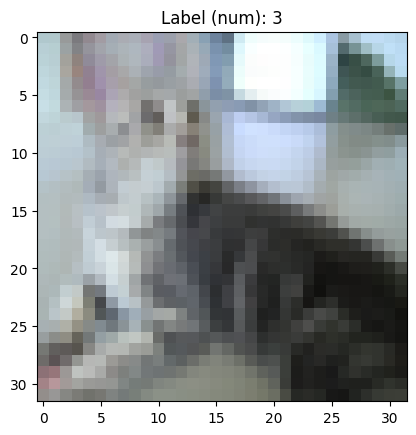

In [ ]:
# Instantiate the CIFAR10Dataset and inspect the first batch of the training data

# YOUR CODE STARTS HERE
CIFAR_Data = CIFAR10Dataset()
X, y = next(iter(CIFAR_Data.get_dataloader(train=True)))
mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3, 1, 1)
std = torch.tensor((0.2470, 0.2435, 0.2616)).view(3, 1, 1)

image = X[0] * std + mean # IF WE DONT UNNORMALIZE WE SEE A SATANIC IMAGE!!!!
#print(f"x: {X}")
plt.imshow(image.permute(1,2,0))
plt.title(f"Label (num): {y[0]}")
plt.show()
# YOUR CODE ENDS HERE


- **Q1.3):** Why did this step take significantly less time to execute than our previous cell that loaded the dataset?

- **A1.3):** Because we only took a batch instead of the full 60k image dataset.

- **Q1.4):** How has the resulting tensor shape and values for each individual image changed from when we explored the images in the dataset directly earlier? Which function reshaped the images? Be specific. 

- **A1.4):** It got reshaped into 3x32x32 and got normalized (between 0-1). The specific function that reshaped the image was the transform.compose, which also normalized it. After unnormalizing and reshaping (permute) we got a cute kitty instead of a strange satanic-esque image.

Next, let's try to apply the simple linear model from Lab-03 to see what accuracy it achieves on this dataset. 

Note the relative brevity of the code for this part - the base `d2l.Classifier` class takes care of much of what we have been adding manually in Lab-03. When creating a classifier in that lab, we inherited the `d2l.Module`, which provides us a more basic outline for the class. Inheriting `d2l.Classifier` means that the `forward()`, `loss()`, `configure_optimizers()`, `training_step()` and `validation_step()` functions are all provided for us. We can still override these as desired.

In [38]:
class LinearClassifier(d2l.Classifier):
    def __init__(self, num_outputs=10, lr=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(            
            nn.Flatten(),
            nn.LazyLinear(num_outputs)
        )

Like we did in Lab-03, we define our own helper function to simplify printing out the results from the D2L trainer board object:

In [39]:
def print_model_results(board):
    # Print out final accuracies and loss values:
    final_tr_loss  = float(board.data['train_loss'][-1][1])
    final_val_loss = float(board.data['val_loss'][-1][1])
    final_val_acc  = float(board.data['val_acc'][-1][1])

    print("\n" + "="*40)
    print(f"Final Training Loss:     {final_tr_loss:.4f}")
    print(f"Final Validation Loss:   {final_val_loss:.4f}")
    print("-"*40)
    print(f"Final Validation Accuracy: {final_val_acc * 100:.2f}%")
    print("="*40)


Let's train our basic model on CIFAR-10, and see what its capable of:

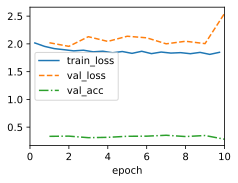


Final Training Loss:     1.8482
Final Validation Loss:   2.5476
----------------------------------------
Final Validation Accuracy: 28.24%


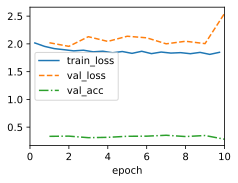

In [40]:
model = LinearClassifier(num_outputs=10, lr=0.01)
model_trainer = d2l.Trainer(max_epochs=10)
# This line assumes you named your instance of CIFAR10Dataset CIFAR_Data. Change if needed. 
model_trainer.fit(model, CIFAR_Data)

print_model_results(model.board)

- **Q1.5):** Did the linear model perform better or worse than you expected? Compare its performance to what you previously achieved on MNIST. 

- **A1.5):** It actually performed better than I expected, although it still sucks. We got about 28% val accuracy, which is much worse than the +95% we got on MNIST. I would like to point out that while it is still really bad we are getting better than random guessing even with the linear model (random guessing would be ~10%). 

### 2. Multi-Layer Perceptons (MLPs) and Nonlinearity

In the previous labs, we developed and evaluated linear models for regression and classification. These models compute a weighted sum of the input features and add a bias to produce a raw output, which we refer to now as $\mathbf{O}$:

$$\mathbf{O} = \mathbf{X} \cdot \mathbf{W} + \mathbf{b}$$

Because this process is purely linear, the resulting decision boundary is a line (or a hyperplane in higher geometric dimensions). This limits the model to problems where the data is linearly separable, in other words, where a straight boundary can distinguish between classes.

However, as we've just seen with CIFAR-10, real-world data is often more complex, with nonlinear relationships between features and outputs. To model these patterns, we introduce nonlinearity into our models. Instead of using a single linear layer, we can stack multiple linear layers with nonlinear activation functions between them. These nonlinear transformations allow the model to learn more complex decision boundaries that better capture the structure of the data.

Let's briefly consider how we can mathematically deepen our model. Say we take the application of our linear layer and label the output $\mathbf{H}$:
$$\mathbf{H} = \mathbf{X} \cdot \mathbf{W_1} + \mathbf{b_1}$$

We use the term $\mathbf{H}$ to represent that this is a *hidden* layer, i.e., it's output is not directly seen in the model's outputs. From this hidden layer we can again apply a second linear layer to get our output $\mathbf{O}$:

$$\mathbf{O} = \mathbf{H} \cdot \mathbf{W_2} + \mathbf{b_2}$$

- **Q2.1:** Explain, in your own words, why this new two-layer linear model would likely not be any more effective than our original one-layer linear model. Be specific, and refer back to the D2L book if needed. 

- **A2.1:**

As hinted at by the previous question, adding linear layers doesn't significantly change the resulting computation on its own. In order to do so, we will be applying a nonlinear *activation* function following each affine transformation. This will prevent the multi-level model from collapsing into a linear model, and allow it to learn more complex features. 

For activation functions, a popular choice is the Rectified Linear Unit (ReLU) function. Mathematically, ReLU is quite simple:

$$ReLU(x) = max(0, x)$$

In plain terms, the ReLU function clamps all negative inputs to 0, and passes through all positive values unchanged. While simple in nature, adding this activation function can have a profound effect of the accuracy of our classifiers. The resulting architecture, where the output of each layer is paired with an activation function, and then successively connected to further layers, is commonly referred to as a *multilayer perceptron (MLP)*.  

Let's visualize the ReLU function:

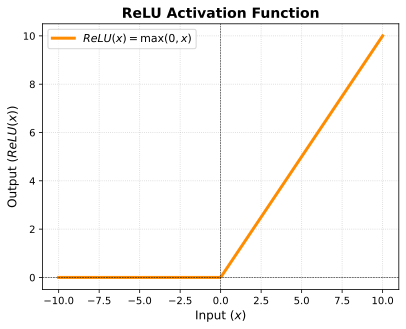

In [41]:
# Range of sample data (-10, 10)
x = torch.linspace(-10, 10, 200)

# Apply ReLU
nnRelu = torch.nn.ReLU() 
y = nnRelu(x)

# Convert tensors to NumPy arrays 
x_np = x.numpy()
y_np = y.numpy()

# Create the plot
plt.plot(x_np, y_np, label=r'$ReLU(x) = \max(0, x)$', color='darkorange', linewidth=3)

# Add visual markers for the axes intersections
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')


plt.title('ReLU Activation Function', fontsize=14, fontweight='bold')
plt.xlabel('Input ($x$)', fontsize=12)
plt.ylabel('Output ($ReLU(x)$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

plt.show()

- **Q2.2:** Consider the positive region of the graph. What is the derivative of this region? Is it a constant value, or does it vary? Why is this derivative meaningful for our neural network?

- **A2.2:** The derivative of the positive region is just a constant 1 (power rule of X). This is good because it is easy to calculate!

Below, implement ReLU from scratch (i.e., without using `nn.ReLU()`). To perform this in the most memory-efficient manner, use `torch.zeros_like()`, a convinient function that creates a tensor with the same shape dimensions as the tensor passed. 

In [43]:
def relu(X):
    # Create zeros array
    zeros = torch.zeros_like(X)
    #perform relu
    return torch.max(zeros, X)


Now that we have our activation function defined, we can implement it as our first hidden layer in our model's neural network. For our first multi-layered model, we will use 2 linear layers with our $ReLU$ layer in between. This impacts the code for our model in a few ways. 

First, for a multi-layered model, each layer will need its own set of weights and biases. Consequently, our `__init__` method needs to not just initialize a $W$ and $b$ as before, but two sets: $W_1$, $W_2$, $b_1$, and $b_2$. 

Secondly, while we still have the arguments `num_inputs` and `num_outputs` to represent the input and output dimensions of our model, we also need a new parameter, `num_hidden`. This value represents the number of neurons / units that are inside the hidden layer. Each unit in our hidden layers are responsible for extracting different characteristics from our input data. The "correct" value for `num_hidden` is something that cannot be precisely reasoned about, although typically one chooses the hidden layer widths to be divisible by larger powers of 2. In general, we determine this value empirically, and for now, we can set it to `256` for our implementation. 

Review examples from Lab-03 where we last implemented a model from scratch, and below, implement the `__init__` method for our new MLP model `MLPClassifier_v1`. As before, you can use `torch.normal()` to initialize the weights and `torch.zeros()` to initialize the biases. Your sizing / initialization of the weights and biases must take the size of the hidden layer `num_hidden` into account.

In [54]:
class MLPClassifier_v1(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, num_hidden, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()

# YOUR CODE STARTS HERE
        self.W1 = torch.nn.Parameter(torch.normal(0, sigma, size=(num_inputs,num_hidden)))
        self.W2 = torch.nn.Parameter(torch.normal(0, sigma, size=(num_hidden,num_outputs)))
        self.b1 = torch.nn.Parameter(torch.zeros_like(torch.Tensor(num_hidden)))
        self.b2 = torch.nn.Parameter(torch.zeros_like(torch.Tensor(num_outputs)))
# YOUR CODE ENDS HERE


Since we inherit `d2l.Classifier`, our model will already default to using `nn.CrossEntropy` for loss and `torch.optim.SGD` for optimizers, meaning we can skip defining these. 

We do need to define our `forward()` pass for our MLP architecture. For this part, we need to 1) flatten each input image in a batch of data to a single array of features (collapse `([width, height, color_channel])` to `([width x height x color_channel])`), 2) apply our first, hidden linear layer ($W_1$ and $b_1$), 3) add our ReLU activation function, and 4) apply our output linear layer. 

- **Q2.3:** Implement the `forward()` pass in the code block below, and briefly explain your code for this part. 

- **A2.3:** We first reshape to flatten the HWC by batch. Then we do a matrix mult with @ and add the bias, then take the Relu to get the input for the hidden layer. Then the final output is the matrix mult of the hidden layer plus bias.

In [55]:
@d2l.add_to_class(MLPClassifier_v1)
def forward(self, X):
        X = X.reshape(X.shape[0], -1)
        hidden = relu(X @ self.W1 + self.b1)
        return hidden @ self.W2 + self.b2

Now, lets train our new MLP model on CIFAR-10 and see how our performance has changed from our prior linear classification approach. Since we are not using `nn.LazyLinear()` which cleverly is able to infer the number of inputs to a layer, we need to specify the number of inputs as `num_inputs=3072` (corresponding to our input dimensions of $32 \times 32 \times 3=3072$):

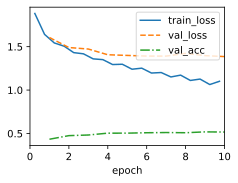


Final Training Loss:     1.1014
Final Validation Loss:   1.3857
----------------------------------------
Final Validation Accuracy: 51.66%


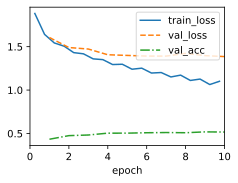

In [56]:
model2 = MLPClassifier_v1(num_inputs=3072, num_outputs=10, num_hidden=256, lr=0.01)
model_trainer2 = d2l.Trainer(max_epochs=10)
model_trainer2.fit(model2, CIFAR_Data)

print_model_results(model2.board)

Our prior approach to building more "concise" models using `nn.Sequential()` makes experimenting with different architectures relatively straightforward. Here, we introduce a version of our MLP that has 2 hidden layers. Note the repeated inclusion of an activation after each linear layer:

In [57]:
class MLPClassifier_v2(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, num_hidden1, num_hidden2, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()

        self.net = nn.Sequential(nn.Flatten(), 
                                 nn.LazyLinear(num_hidden1), 
                                 nn.ReLU(), 
                                 nn.LazyLinear(num_hidden2), 
                                 nn.ReLU(), 
                                 nn.LazyLinear(num_outputs))
    
    def forward(self, X):
        return self.net(X)

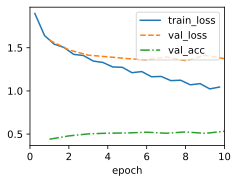


Final Training Loss:     1.0449
Final Validation Loss:   1.3735
----------------------------------------
Final Validation Accuracy: 53.28%


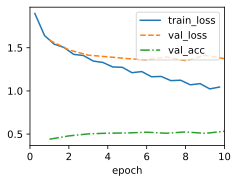

In [58]:
model3 = MLPClassifier_v2(num_inputs=3072, num_outputs=10, num_hidden1=256, num_hidden2=128, lr=0.01)
model_trainer3 = d2l.Trainer(max_epochs=10)
model_trainer3.fit(model3, CIFAR_Data)

print_model_results(model3.board)

- **Q2.4:** For both `MLPClassifier_v1` and `MLPClassifier_v2`, how much did our accuracies improve from the linear model? Are the loss values meaningfully lower? 

- **A2.4:** Our val accuracy nearly doubled from the linear model! THe loss values also decresed significantly, although the training loss continued to fall while the validation loss stalled out.

### 3. Working with Convolutions

While MLPs improved our CIFAR-10 classification performance, we are still far from achieving high accuracy (95%+). To improve further, we introduce convolutions and Convolutional Neural Networks (CNNs).

The *convolution operator* is a mathematical operation that combines two functions to describe how one modifies the other. As you may have seen in previous classes, in continuous form, convolution is defined as:

$$(f * g)(t) = \int_{-\infty}^{\infty} f(\tau)\, g(t - \tau)\, d\tau$$

where $f$ is typically the input signal and $g$ is a *kernel* (or *filter*). In practice, especially in machine learning, we usually work with discrete data. For a 2D image, the discrete convolution is written as

$$(f * g)(i, j) = \sum_m \sum_n f(i - m, j - n)\, g(m, n)$$

where the kernel $g$ is applied over local neighborhoods of the input $f$.

In image processing and CNNs, convolution can be interpreted as a "sliding window" operation. A small kernel (e.g., $3 \times 3$) moves across the image, and at each position, it computes a weighted sum of nearby pixel values. This operation extracts local features such as edges, textures, or patterns. By applying multiple kernels, a model can learn to detect different types of features, building increasingly complex representations as layers are stacked. 

CNNs are extremely powerful for image classification because they exploit spatial invariance; by applying the same filter across different spatial regions, they can detect target figures regardless of where they are located. For example, hats are usually worn on top of somebody's head, likely in the upper half of an image; however, we want our model to successfully detect a hat even if its located on the ground, at the bottom of the image. 

Converting to our prior representation for a hidden layer output $\mathbf{H}$, and taking into account that as we may have multiple channels in our input (e.g., 3 channels for RGB input images), and consequently may want multiple channels in our output, our discrete convolutional layer can be summarized with the following equation:

$$[\mathbf{H}]_{i,j,d} = \sum_{a=-\Delta}^{\Delta} \sum_{b=-\Delta}^{\Delta} \sum_{c} [\mathbf{V}]_{a,b,c,d} [\mathbf{X}]_{i+a, j+b, c}$$

Here, $\mathbf{H}$ is a third-order tensor representing the output of this layer, $\mathbf{X}$ is our third-order input tensor, and $\mathbf{V}$ is our kernel or filter for this layer. $\mathbf{V}$ has four dimensions - 1) the kernel width, 2) the kernel length, 3) the kernel channel depth, and 4) the number of kernels. 

Another term you will see for $\mathbf{H_d}$ is that it is a *feature map* for this layer. After our activation function is applied it is often referred to as an *activation map*. 

- **Q3.1:** Considering the final equation for the convolutional layer, how many nested `for` loops would you need to calculate this using raw Python loops? What would each one handle looping through? Be specific. 

- **A3.1:** 


- **Q3.2:** Suppose you have a standard $32 \times 32$ pixel CIFAR-10 image. You slide a $3 \times 3$ kernel across it moving one pixel at a time (this is called the *stride*). What will the height and width of the output feature map be?

- **A3.2:** 


While convolutional layers can be added to our concise model implementation using Pytorch's `nn.Conv2D()`, we will gain a better understanding of how kernel operators work by implementing it ourselves. 

The trickiest part, if you haven't done this type of coding before, is to implement the "sliding window" logic, where we loop our kernel window of size `kh` x `kw` over our input of size `h` x `w`. The actual computation is just another multiply-accumulate operation. Below, complete the implementation of `corr2d` (technically, given the orientation of our kernel, we are describing a 2D cross-correlation in our equation above. The distinction between cross-correlation and convolution is not important to us as it relates to CNNs). 

Using Python's built-in matrix operations, you should be able to do this with just two `for` loops. 

In [ ]:
def corr2d(X, K):

    #X is 2D input matrix of shape (height, width)
    #K is 2D kernel matrix of shape (height, width)
    h, w = X.shape
    kh, kw = K.shape
    
    # Spatial output dimension math (Assuming stride=1, padding=0)
    out_h = h - kh + 1
    out_w = w - kw + 1
    
    # Pre-allocate the output feature map with zeros
    Y = torch.zeros((out_h, out_w))

    # Perform element-wise multiplication of the window with K and sum the total

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE
    return Y


- **Q3.3:** Run the test below to ensure that your cross correlation math is correct. Describe your debugging process, what mistakes (if any) you made while implementing `corr2D`, and how you fixed them. 

- **A3.3:** 


In [ ]:
# Verification cell (run this to test your corr2d function)

# Input Test matrix
X_test = torch.tensor([[0.0, 1.0, 2.0], 
                       [3.0, 4.0, 5.0], 
                       [6.0, 7.0, 8.0]])

# Kernel Test matrix
K_test = torch.tensor([[0.0, 1.0], 
                       [2.0, 3.0]])

try:
    student_output = corr2d(X_test, K_test)
    print("Your Output:\n", student_output)
    if torch.allclose(student_output, torch.tensor([[19., 25.], [37., 43.]])):
        print("\nYour 2D cross-correlation math passes this test case. Proceed. ")
    else:
        print("\nThe dimensions match, but the values are incorrect. Double check your multiplication and sum sequence!")
except Exception as e:
    print(f"\nExecution failed: {e}")

With our 2D cross correlation calculation working, we can construct our full 2D convolution layer. In `__init__`, initialize the weights the kernel. Assume that `kernel_size` is a tuple: `(width, height)`

In [ ]:
class MyConv2D(nn.Module):

    def __init__(self, kernel_size):
        super().__init__()

        # YOUR CODE STARTS HERE

        # YOUR CODE ENDS HERE

Now, in the `forward()` method you need to call our `corr2d()` function above with the arguments `x` and `self.weight`. 

In [ ]:
@d2l.add_to_class(MyConv2D)  #@save
def forward(self, x):
        # YOUR CODE STARTS HERE

        # YOUR CODE ENDS HERE

Let's test our from-scratch `MyConv2D` layer on a batch of CIFAR images. 

In [ ]:
mock_cifar_batch = torch.randn(32, 3, 32, 32)

# Remove the channels for now: new shape is (Batch Size=32, Height=32, Width=32)
single_channel_batch = mock_cifar_batch[:, 0, :, :]

# Instantiate Conv2D layer with a 3x3 kernel size
print("Initializing custom D2L Conv2D layer...")
model_layer = MyConv2D(kernel_size=(3, 3))

# Process the batch through our loops
outputs = []
with torch.no_grad():
    # Loop through the batch dimension to process each 2D grid individually
    for i in range(single_channel_batch.shape[0]):
        # Pass the 2D image frame through the layer
        out_frame = model_layer(single_channel_batch[i])
        outputs.append(out_frame.unsqueeze(0))
        
    # Stack individual processed frames back into a single batch tensor
    batch_output = torch.cat(outputs, dim=0)

print(f"-> Input Batch Shape:  {single_channel_batch.shape}")
print(f"-> Output Batch Shape: {batch_output.shape}")


At this point, we have implemented a working spatial convolution window from scratch. Great! However, two factors will require that we switch to PyTorch's built-in functions when building our CNN models:

1) There are several other features that our convolutional layers need that we haven't implemented yet. For example, we need to support multiple input and output channels. 
2) Even if we implemented these additional features from scratch, the resulting performance of even simple custom CNNs on CIFAR-10 and more advanced datasets would be slower than we can justify. 

- **Q3.4:** Review Pytorch's documentation for [Conv2D()](https://docs.pytorch.org/docs/2.12/generated/torch.nn.Conv2d.html). What features would you need to add to your `MyConv2D()` module to match `Conv2d()`'s functionality? Be specific. 

- **A3.4:** 


Before doing so, we need to address a key issue: dimensional growth. Although a single convolution reduces spatial size (e.g., from $32 \times 32$ to $30 \times 30$ when using a $3 \times 3$ kernel and no padding), it also can produce multiple feature maps. For example, if we were to configure `Conv2D()` to use `64` output channels, the resulting tensor would be of size $30 \times 30 \times 64 = 57,600$ values. As we add successive layers, these dimensions can grow quickly, increasing both memory usage and computation time. 

To control this, we implement a transformation known as *pooling*. Pooling applies a sliding window similar to convolution, but instead of computing a weighted sum, it reduces the dimensionality of the data. For example, in *max pooling*, which we will use in this lab, the operator selects the largest value in each window. Applying a $2 \times 2$ max pool reduces each $2 \times 2=4$ value region to a single value, effectively halving the width and the height. 

Since pooling follows the same sliding-window pattern as convolution, the implementation is similar. Below, complete the `pool2d()` function by reusing the looping logic from `corr2d`, returning the maximum value within each window. Here, we also need to implement the concept of a `stride`, which slides our window more than one element at a time, skipping the intermediate locations. 

In [ ]:
def pool2d(X, pool_size=(2, 2), stride=2):
    h, w = X.shape
    ph, pw = pool_size
    
    # Calculate output dimensions based on the stride step
    out_h = (h - ph) // stride + 1
    out_w = (w - pw) // stride + 1
    
    # Initialize the downsampled output matrix
    Y = torch.zeros((out_h, out_w))

    # Find the maximum value inside this window and save it to Y[i,j] (hint: use torch.max())

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE
    
    return Y

Now, run the verification test case below to ensure that your function is working properly. 

In [ ]:
# Verification test for Max Pooling
X_pool_test = torch.tensor([[0.0, 1.0, 2.0, 3.0],
                            [4.0, 5.0, 6.0, 7.0],
                            [8.0, 9.0, 10.0, 11.0],
                            [12.0, 13.0, 14.0, 15.0]])

try:
    student_pool = pool2d(X_pool_test, pool_size=(2, 2), stride=2)
    print("Your Pooled Output:\n", student_pool)
    if torch.allclose(student_pool, torch.tensor([[5., 7.], [13., 15.]])):
        print("\nYour from-scratch Max Pooling function passes the test.")
except Exception as e:
    print(f"\nExecution failed: {e}")

### 4. Convolutional Neural Networks (CNNs)

We now have the tools to be able to describe our convolutional layers using PyTorch's built-in `nn.Conv2D()` function:
- `in_channels`: this parameter describes how many channels are input to the layer. For our initial layer, we can set this value to 3 for our RGB CIFAR-10 data
- `out_channels`: this is a hyperparameter we tune for how many feature maps we want stacked in the output. 
- `kernel_size`: can either be a tuple (as we defined it for our custom implementation), or just a single integer value. For our first CNN, we will define a $3 \times 3$ kernel and can set `kernel_size=3`. 
- `padding`: to deal with the issue we saw, where we out output gets shrunk by the convolution operation, we can set this parameter to effectively add an empty border around the input, so that for a $32 \times 32$ input, we can continue to have a $32 \times 32$ sized output.  

- **Q4.1:** Review the code block below, and describe how the size and shape of an input batch of CIFAR-10 data will be changed as it is processed layer-by-layer through the network. Be specific. 

- **A4.1:** 

In [ ]:
class CNNClassifier_v1(d2l.Classifier):
    def __init__(self, num_classes=10, lr=0.01):
        super().__init__()
        self.save_hyperparameters()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),            
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),            
            nn.Linear(4096, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
        

Some additional things to note about our first CNN:
- We still use our `ReLU()` activation function after the `Conv2D()` layer. 
- We aren't using `Flatten()` as our first stage here, as `Conv2D()` was designed to handle our 4th-order tensors of shape `[batch_size, num_channels, height, width]`. We still `Flatten()` before our linear layers. 

More importantly, note also that our thought process should be starting to evolve: instead of worrying about the individual operations, we are thinking in terms of the connectivity between layers. And while there are "lazy" versions of these transformations (for example, there is a  [`LazyConv2D()`](https://docs.pytorch.org/docs/2.12/generated/torch.nn.LazyConv2d.html) equivalent where you don't have to specify the input dimensions), in general we have to design our models with the input and output dimensions of each layer as a primary consideration. 

Let's train our model on CIFAR-10:

In [ ]:
model4 = CNNClassifier_v1(num_classes=10, lr=0.01)
model_trainer4 = d2l.Trainer(max_epochs=10)
model_trainer4.fit(model4, CIFAR_Data)

print_model_results(model4.board)

Experiment with both the hyperparameters and model architecture for `CNNClassifier_v1` to find a more effective combination.


- **Q4.2:** Summarize the changes you made to achieve the best performance in the model (learning rate, layers added, epoch count, etc). What was your best training and testing accuracy?

- **A4.2:** 

As you can start to imagine, the possibilities for our CNN architecture are nearly endless. We can gain some additional insights by focusing on some historically influential examples. It is important to note that while the following model architectures are not considered state-of-the-art today (given advancements in theory, software frameworks, and hardware capabilities), they are still very relevant for learning how the design of CNNs has evolved over time. Today, it is still more common that you will adapt a pre-existing model with pre-trained weights vs designing your own model from base principles.

The first influential CNN architecture we will explore is [LeNet](https://en.wikipedia.org/wiki/LeNet), named after influential machine learning practitioner [Yann LeCunn](https://en.wikipedia.org/wiki/Yann_LeCun). LeNet is composed of two separate parts: 2 convolutional layers that make up the "convolutional encoder", and a dense block that consists of 3 fully connected layers. It is possible that in your exploration of our `CNNClassifier_v1` above, you wound up designing something similar. 

A PyTorch version of LeNet is provided below, with some small liberties taken with regards to the activation functions:

In [ ]:
class LeNet(d2l.Classifier):  #@save
    
    def __init__(self, lr=0.01, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5, padding=2), nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.LazyConv2d(16, kernel_size=5), nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Flatten(),
            nn.LazyLinear(120), nn.ReLU(),
            nn.LazyLinear(84), nn.ReLU(),
            
            nn.LazyLinear(num_classes)
        )


The D2L framework provides a useful helper function, `layer_summary()`, which traces through the dimensions of our data through a network. We provide it a tuple representing the input shape, which for our CIFAR-10 data, is still `(batch_size, 3, 32, 32)`. 

In [ ]:
LeNet().layer_summary((1, 3, 32, 32))

- **Q4.3:** In the code block below, create an instance of `LeNet()` with a learning rate of 0.01. Train this model on CIFAR-10 and print out the resulting training and validation results using `print_model_results()`. How does LeNet compare to your custom CNN from before? Why might this be the case? 

- **A4.3:** 

In [ ]:
# Instantiate the model and trainer, and fit using the CIFAR_Data. 

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


### 5. A Second Image Dataset
Going forward, and especially in the future when you will want to apply what you've learned in this course to real-world tasks, your data is not going to come in a pre-packaged, PyTorch friendly format. Fortunately, we can use other Python library calls to convert less standard datasets into a format we can process with our knowledge of CNNs.  

We'll start with the [PC Parts Image Dataset](https://www.kaggle.com/datasets/asaniczka/pc-parts-images-dataset-classification/data), curated by a frequent contributor to the Kaggle data science competition platform. PC Parts is a collection of Google Image search results for the basic components of a PC (e.g. "mouse", "speakers"), all scaled to $256 \times 256$ resolution. Here, we start by simply downloading and unzipping the files. 

In [ ]:
import os
import requests
import zipfile

# URL and downloaded filename
url = "https://www.kaggle.com/api/v1/datasets/download/asaniczka/pc-parts-images-dataset-classification?dataset_version_number=1"
folder = './data/'
fname = os.path.join(folder, 'pc_parts.zip')


if os.path.exists(fname):
    print(f'File {fname} already exists.')
else:
    # Download the file at url and save as fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)

    # Unzip the file fname
    print(f'Extracting {fname} to {folder}...')
    fp = zipfile.ZipFile(fname, 'r')
    fp.extractall(folder)

# Final location of dataset files
data_path = os.path.join(folder, 'pc_parts/')
print(f'Path to dataset files: {data_path}')

We can convert these files into a PyTorch dataset using a function named `ImageFolder()`, which was designed to handle sets of images in exactly this format. Later, when we construct a dataloader class, we will pass in a similar set of transformations as before. 

The resulting variable `pcparts` will automatically assign the classes based on the subfolders of images inside our main folder.

In [ ]:
pcparts = torchvision.datasets.ImageFolder(
    root=data_path,
    transform=None
)

print(pcparts.classes)
print(pcparts.imgs)
print(pcparts.targets)

- **Q5.1:** How is the datatype associated with your `pcparts` variable different from the CIFAR-10 dataset? What additional steps will be required to work with `pcparts`? 

- **A5.1:** 

In the following code block, construct a bar chart for the class distribution of this dataset. Your code should be nearly identical to what we previously did for CIFAR-10. 

In [ ]:
# Count the frequencies for each label
pcparts_label_series = pd.Series(pcparts.targets)
class_counts = pcparts_label_series.value_counts().sort_index()

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


As hinted at above, we don't actually know much about the images in our new dataset. Typically, we would want to process images at the same resolution and color depth, so let's confirm what we have with `pcparts`:

In [ ]:
from PIL import Image

# Grab a few raw image paths directly from ImageFolder
sample_paths = [pcparts.imgs[i][0] for i in range(0, len(pcparts), len(pcparts)//5)]

print("Sample Image Resolutions (Width, Height):")
for path in sample_paths:
    with Image.open(path) as img:
        print(f"  Folder: {os.path.basename(os.path.dirname(path))} -> Size: {img.size} | Mode: {img.mode}")

- **Q5.2:** How would this $256 \times 256$ input size impact either of the CNN models we have previously worked with? Be specific. 

- **A5.2:** 

Let's display a few images.  We haven't actually converted them to PyTorch tensor objects yet, so our code looks a little different than our CIFAR-10 example. 

In [ ]:
import random

# Set up matplotlib figure grid
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

# Sample 8 images from pcparts
samples = random.sample(pcparts.imgs, 8)

for i in range(len(samples)):
    # Load each image from our samples using PIL
    with Image.open(samples[i][0]) as img:

        # Plot on grid
        axes[i].imshow(img)
        axes[i].set_title(pcparts.classes[samples[i][1]])
        axes[i].axis('off')

plt.tight_layout()
plt.show()

As previously mentioned, the input image size can have an impact on our model. There is a tradeoff to consider: maintaining higher dimensions allows for more features that our CNN can learn from. On the other hand, it may mean more noise to filter out, and ultimately require more training. As we build our dataloader for the this dataset, let's add the ability to resize our images. 

Complete the `__init__` code block below. For our data transformations, convert the input to tensors, normalize the values (we could calculate the mean and stddev of the dataset, but for now normalizing to `[0.5, 0.5]` is sufficient), and also resize the input to the user-specified dimensions.

In [ ]:
class PCPartsData(d2l.DataModule):
    
    def __init__(self, data_dir, batch_size=64, resize=(128, 128)):
        super().__init__()
        self.save_hyperparameters()

        # Use transforms.Compose() to resize and normalize images
    
# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE

        # Load the complete dataset from the directory structure
        self.full_dataset = torchvision.datasets.ImageFolder(
            root=data_dir,
            transform=self.transform
        )

        # 80/20 train/validation split
        train_size = int(0.8 * len(self.full_dataset))
        val_size = len(self.full_dataset) - train_size
                
        print(train_size, val_size)
        self.train_set, self.val_set = torch.utils.data.random_split(
            self.full_dataset, 
            [train_size, val_size],
        )
        
        self.num_classes = len(self.full_dataset.classes)
        self.classes = self.full_dataset.classes

    def get_dataloader(self, train):
        data = self.train_set if train else self.val_set
        return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train,
                                           num_workers=self.num_workers)


Check that our batches are working properly before continuing: create an instance of our PC Parts data class, and grab a sample batch. Ensure that your `X` tensor has the shape `([64, 3, 224, 224])` (by setting `resize` to `(224, 224)`), and that your `y` tensor has the shape `([64])`. If this is not the case, you must go back and revise your data class implementation above.

In [ ]:
# Review how the first batch looks

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


We are now ready to begin constructing our CNN architecture; we will leave it up to you to determine the proper sequencing of the layers to ensure that the model performs as well as possible, and that the dimensions are maintained. 

Keep in mind that the last output layer must be Linear; to save yourself the calculation of the total dimension space, you can use `LazyLinear()` where you only need to pass an argument for the output dimension, which is the number of classes. 

Additionally, the `LazyLinear()` layer will expect a 2D matrix, but the rest of your architecture will result in a 4D feature map; hence, don't forget to use a `Flatten()` layer before your any linear layers. 

Finally, for working with this dataset, we will use the [Adam](https://d2l.ai/chapter_optimization/adam.html) optimizer vs our standard SGD, as should converge faster on this more computationally heavy dataset. 

- **Q5.3:** Explain each line of the code you added to the `CNNClassifier_v3` `implementation below.  Be specific.  

- **A5.3:** 

In [ ]:
class CNNClassifier_v3(d2l.Classifier):
    def __init__(self, num_classes, lr=0.001):
        super().__init__()
        self.save_hyperparameters()

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


@d2l.add_to_class(CNNClassifier_v3)
def configure_optimizers(self):
    return torch.optim.Adam(self.parameters(), self.lr)

CNNClassifier_v3(num_classes=14).layer_summary((64, 3, 224, 224))

Complete the code block below to see how your model performs. Note that this dataset has more than 10 classes, so do not set `num_classes=10` like before. 

In [ ]:
# Instantiate the model and trainer, and fit using the PC_Data. 

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


It's likely your model didn't perform tremendously at this task. Classifying "real-world" images is much harder than handling very well-established benchmarks!

This result leads us to introduce our final CNN of this lab, the famous [AlexNet](https://en.wikipedia.org/wiki/AlexNet). While in many ways it can be seen as a direct evolution of the LeNet architecture, the key contribution of AlexNet was the first successful demonstration that so-called "deep" CNNs can be effective, given enough training data, compute, and time. Our class textbook is called D2L, for *Dive into Deep Learning*, and one unstated aspect of this is that what makes a network "deep" is somewhat arbitrary. Our working definition is that any MLP with more than one hidden layer can be thought of as a deep neural network (sometimes abbreviated as DNN). 

- **Q5.4:** A slightly modernized version of `AlexNet()` is provided below. What is new in this implementation compared to the prior networks you've explored? Be specific.  

- **A5.4:** 

In [ ]:
class AlexNet(d2l.Classifier):
    def __init__(self, lr=0.001, num_classes=14):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(96, kernel_size=11, stride=4, padding=1),
            nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(256, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(256, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2), nn.Flatten(),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(p=0.5),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(p=0.5),
            nn.LazyLinear(num_classes)
        )


@d2l.add_to_class(AlexNet)
def configure_optimizers(self):
    return torch.optim.Adam(self.parameters(), self.lr)

Again, we can use the `layer_summary()` PyTorch function to better understand the dimensions as our data moves through the network. `AlexNet()` assumes $224 \times 224$ resolution images, so the shape of our `X` will be `([64, 3, 224, 224])`.

In [ ]:
AlexNet().layer_summary((64, 3, 224, 224))

Let's run `AlexNet()` on CIFAR-10 first to see how it does. You will possibly need to go back to your `CIFARDataset` implementation and add a `Resize()` block to the input transformations first, similar to what we've done for `PCPartsData`:

In [ ]:
CIFAR_Data = CIFAR10Dataset(batch_size=64, resize=(224, 224))
model7 = AlexNet(num_classes=10, lr=0.001)
model_trainer7 = d2l.Trainer(max_epochs=10)
model_trainer7.fit(model7, CIFAR_Data)

print_model_results(model7.board)

You likely noticed that while our `AlexNet()` architecture is reasonably effective on CIFAR-10, there is now a significant computational overhead. Feel free to experiment with PC Parts again below, but in the interest of time, it's not required (you can skip the following code block). 

In [ ]:
PC_Data = PCPartsData(data_path, batch_size=64, resize=(224, 224))

model8 = AlexNet(num_classes=14, lr=0.001)
model_trainer8 = d2l.Trainer(max_epochs=20)
model_trainer8.fit(model8, PC_Data)

print_model_results(model8.board)

- **Q5.5:** If you ran the above code (or just take our word for it), you will conclude that this AlexNet model, which was considered state-of-the-art not too long ago, still struggles in our environment to accurately classify images of common PC parts. Attempt to explain what might be happening. For this question, you may be able to reason about it directly, but you can also search and learn more about AlexNet. Cite any sources you used. 

- **A5.5:** 

Back in Lab-03, we visualized our weight matrices to gain some intuition as to how the various MNIST digits were being detected by our linear classifier. We can do something similar for CNNs - the following code block visualizes the first AlexNet layer's filters learned on CIFAR-10. 

In [ ]:
# Read back the first layer's weights and visualize them as images
first_layer_weights = model7.net[0].weight
first_layer_weights = first_layer_weights.permute(0, 2, 3, 1).detach()

n_filters = first_layer_weights.shape[0]
cols = 12
rows = (n_filters + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols, rows), squeeze=False)
fig.subplots_adjust(wspace=0.02, hspace=0.02)

for ax in axes.flat:
    ax.axis('off')

for i in range(n_filters):
    ax = axes.flat[i]
    ax.imshow(first_layer_weights[i, :, :, :] + 0.5, cmap='gray')
    ax.axis('off')

plt.show()


- **Q5.6:** Why do many of the filters in the first convolutional layer look similar? What does this tell you about the role of early layers in a CNN? 

- **A5.6:** 

For our final attempt at classifying these PC parts, we look to [EfficientNet](https://github.com/tensorflow/tpu/tree/master/models/official/efficientnet), a relatively modern family of CNNs designed to make more efficient use of memory and compute resources. 

While the model architecture itself is innovative, what is especially helpful for us is that EfficientNet is designed to facilitate *transfer learning*, where the model is pre-trained on a variety of datasets and is then tuned further for the task at hand. 

In our case, we build up an implementation of `EfficientNet()` that starts with the previously trained EfficientNet_B0 model. We freeze these pre-trained layers, and then add a final linear layer to learn the differentiating features of our target dataset. 

In [ ]:
class EfficientNet(d2l.Classifier):
    def __init__(self, lr=0.001, num_classes=14):
        super().__init__()
        self.save_hyperparameters()
        
        # Get model weights
        model_weights = (torchvision.models.EfficientNet_B0_Weights.DEFAULT)
        
        # Get model
        model = (torchvision.models.efficientnet_b0(weights=model_weights))
        
        # Freeze Model Parameters
        for param in model.features.parameters():
            param.requires_grad = False
        
        # Verify the number of features in the model before the classifier
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224)
            features = model.features(dummy_input)
            print(f"Output features shape before classifier: {features.shape}")

        # Define new classifier and push to the target device
        num_features = features.shape[1]  # Number of features from the penultimate layer
        model.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.2, inplace=True), 
            nn.Linear(
                in_features=num_features, out_features=num_classes, bias=True
            )
        )

        self.net = model

The training process is going to be relatively fast, and so we will run our trainer with `max_epochs=25`:

In [ ]:
model9 = EfficientNet(num_classes=14, lr=0.001)
model_trainer9 = d2l.Trainer(max_epochs=25)
model_trainer9.fit(model9, PC_Data)

print_model_results(model9.board)


- **Q5.7:** EfficientNet and AlexNet have similar levels of complexity, but EfficientNet (using transfer learning) trains much faster. Consider how the model is initialized and what parameters are being updated. Why does this lead to reduced training time?

- **A5.7:** 

### 6. A Tabular Data Example

CNNs are most commonly applied to image data, where they are highly effective. However, their use on non-image data is less explored. In this section, we investigate whether CNNs can also be effective for tabular data.

To do this, we use the [RT-IOT2022](https://archive.ics.uci.edu/dataset/942/rt-iot2022) dataset, a cybersecurity-focused dataset derived from real-time IoT systems spanning a variety of devices. Like the TUANDROMD dataset from Lab-03, it involves classifying benign and malicious behavior, but here, the data includes multiple types of simulated attacks, such as SSH brute-force, DDoS, and Nmap scans. The goal of the model is to classify each data sample according to its attack type.

We begin by loading the dataset as a Pandas DataFrame, which allows for straightforward exploratory data analysis.

In [ ]:
df = pd.read_csv("data/RT_IOT2022.csv")
df.head()

The column above titled `no` is just the index re-written; we don't need it, so we drop it. 

In [ ]:
df = df.drop(columns=['no'])
df.tail()

In [ ]:
df.shape

Make sure to take note of the data types of the different features in the dataframe:

In [ ]:
df.info()

In [ ]:
df.describe()

The target / label is the last column, `Attack_type`. In the code block below, plot the distribution of different attack types below as a bar chart of the counts of each attack type. This will show us the class distribution of the dataset. 

In [ ]:
# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


- **Q6.1:** Looking at the class distribution, it is clearly heavily imbalanced. If you measure your model's accuracy purely on accuracy, you could hypothetically just guess `DOS_SYN_Hping` every time and get over 70% accuracy. With an imbalanced dataset like this, how could we analyze our model's performance other than just using the raw training / validation accuracy number?

- **A6.1:**

Let's now construct a correlation matrix of the numerical features in the dataset. Look at some of the features included below:

In [ ]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
numeric_df.head()

Now, plot a simple correlation matrix heatmap using `numeric_df`. We have done this before in Lab-02 using the Pandas `.corr()` function, so refer back to that lab if you need a refresher.

In [ ]:

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


Our goal here is to use CNN architectures on this RT-IOT dataset. The most common approach here would be to use 1 dimensional convolutional layers (we have been using `Conv2D()`, but there is also a `Conv1D()`). An alternative approach is to pre-process our data to conceptualize it as grayscaled "images", using a technique known as *feature spatial mapping*. 

The dataset contains 81 numeric features, which conveniently forms a perfect square. This allows us to reshape each feature vector into a $9 \times 9$ matrix. If the number of features were not a perfect square, we would reshape to the nearest square size and pad the remaining entries with zeros.

With this representation, we can construct our data class. In the `__init__` method, we process `numeric_df` into input features `X` and `label_series` into labels `y`, along with specifying parameters such as batch size and the train/validation split.

Finish the `__init__` implementation below by adding the following steps:
- Randomize your dataseries using Pandas function `.sample()`. Note that our D2L DataLoader already shuffles the training set, but the validation set might otherwise be too imbalanced to be useful. 
- Extract `X_data` and `Y_data` as the numeric and label values of our original `df` as we did above. We've labelled the input `full_df` to make it clear you are processing the full dataframe and not the slightly pre-processed verison.
- Normalize `X_data` so that it has a `mean=0` and `std=1`
- `reshape()` the data into a 2D grid (it will need one "color" channel). 
- Upscale the 2D grid from $9 \times 9$ to $64 \times 64$. We'll explore the reasons for doing this in a little bit. 
- Convert the `label_series` from categorical attack types to numeric indexing (0-10). This can be done using the Pandas function [`pd.factorize()`](https://pandas.pydata.org/docs/reference/api/pandas.factorize.html). Note from this documentation that the function returns a tuple, which your code must unpack appropriately; the second return value, which is a list of the unique labels, can be conviniently stored as `self.classes`. 
- Convert to tensors and store as `self.X` and `self.y` as we did back in Lab-02. 

In [ ]:
from numpy.core.numeric import indices


class CyberDataset(d2l.DataModule):
    def __init__(self, full_df, batch_size=64, train_val_split=0.8):
        super().__init__()
        self.save_hyperparameters()

        # Go step-by-step here, and debug as you go. 
        full_df = full_df.drop(columns=['no'])  # Drop the 'no' column if it exists

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE

        # An example of using torch.nn.functional.interpolate to upscale the 9x9 images to 64x64. 
        #X_upscaled = torch.nn.functional.interpolate(X_tensor, size=(64, 64), mode='bilinear', align_corners=False) 



        # Allocate training and validation sizes. Adjust this code if your outputs are named differently. 
        num_samples = len(self.y)
        self.num_train = int(num_samples * train_val_split)
        self.num_val = num_samples - self.num_train
        

    def get_dataloader(self, train):
        i = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader((self.X, self.y), train, i)


- **Q6.2:** Briefly explain what each line of code that you added to `__init__` above is doing. Be specific.  

- **A6.2:**



Ultimately, we want to apply modern, potentially pre-trained CNN architectures to any dataset. These models are designed to operate on larger input images, so our $9 \times 9$ representations must be resized to match the expected input dimensions (e.g., $64 \times 64$).

The easiest way to accomplish this is to use PyTorch's [functional.interpolate()](https://docs.pytorch.org/docs/2.12/generated/torch.nn.functional.interpolate.html) function to upscale the images. This operation increases the spatial resolution by interpolating between existing pixel values, effectively spreading the original information across a larger grid. A line of code for this transformation has been provided but is currently commented out: once your implementation is otherwise complete, you should enable it.

Although this resizing does not introduce new information, it allows us to leverage powerful pretrained architectures that are optimized for larger image inputs.


- **Q6.3:** As mentioned above, upscaling from $9 \times 9$ to $64 \times 64$ does not add new information to the data. What are the potential drawbacks of this approach?

- **A6.3:** 

You can now instantiate a dataset and check that the batches behave as they should. 

In [ ]:
full_df = pd.read_csv("data/RT_IOT2022.csv")
CyberData = CyberDataset(full_df, batch_size=64)

print(CyberData.classes)

X, y = next(iter(CyberData.train_dataloader()))
print("Batch X shape:", X.shape)  # Should output: torch.Size([64, 1, 64, 64])
print("Batch y shape:", y.shape)  # Should output: torch.Size([64])
print("Batch y values: ", y)  # Should output unique label indices in the batch

Make sure that your `X` has the shape `([64, 1, 64, 64])` and that your `y` has the shape `([64])` before proceeding. Note that the shape of X would have been `([64, 1, 9, 9])` if we didn't upscale it; if this is your output, it means you forgot to pass the upscaled version of X into the dataloader. 

We have now reshaped our tabular data to behave like simple 2D "images", even though it originally existed as rows of features. At first, this may seem counterintuitive...unlike pixels in an image, these features do not inherently have spatial or local relationships. To better understand this difference, it is helpful to visualize the matrices we have constructed from the data:

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.ravel()

num_plots = min(16, X.shape[0])

for i in range(num_plots):
    matrix_2d = X[i].squeeze().numpy()
    label_idx = y[i].item()
    class_name = CyberData.classes[label_idx]

    im = axes[i].imshow(matrix_2d, cmap='viridis')
    axes[i].set_title(f"Sample {i+1}\nClass: {class_name}", fontsize=9, fontweight='bold')
    axes[i].axis('off')

for ax in axes[num_plots:]:
    ax.axis('off')

fig.subplots_adjust(left=0.08, right=0.92, top=0.95, bottom=0.05, wspace=0.22, hspace=0.18)
fig.colorbar(im, ax=axes, shrink=0.8, pad=0.03, location='left')
plt.suptitle("Sample Data Visualizations (64x64 Feature Grids)", fontsize=14, fontweight='bold', y=0.98)
plt.show()

The images shown above are the upscaled $64 \times 64$ representation of the feature data. Numerically positiveH values appear in yellow/green, while lower values are shown in purple. This is a randomized sample of the data, so most of the images above will correspond to `DOS_SYN_Hping`, the most common (70+%) of the cyber-attack types.  

While many features take on lower values, there are also distinct regions where feature values are higher, creating visible structure within each example.

Although the features are arranged on a grid, their placement is not spatially meaningful in the same way as pixels in a natural image. Instead, the grid serves as a structured representation of the feature space, grouping values in a consistent layout that the CNN can process. Any relationships learned by the model are based on patterns in the data rather than true physical proximity.

With this representation in place, we can now define a CNN architecture to train on the transformed RT-IOT dataset.

In [ ]:
class CNNClassifier_v4(d2l.Classifier):
    def __init__(self, lr=0.001, num_classes=2):
        super().__init__()
        self.save_hyperparameters()
        
        self.net = nn.Sequential(
            # Block 1: Input [Batch, 1, 64, 64] -> Output [Batch, 16, 16, 16]
            nn.Conv2d(1, 16, kernel_size=7, stride=4, padding=2),
            nn.ReLU(),
            
            # Block 2: Input [Batch, 16, 16, 16] -> Output [Batch, 32, 8, 8]
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            
            # Block 3: Input [Batch, 32, 8, 8] -> Output [Batch, 64, 4, 4]
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            
            # Global Average Pooling collapses spatial grid to [Batch, 64, 1, 1]
            nn.AdaptiveMaxPool2d((1, 1)),
            nn.Flatten(), 
            
            # Final output mapping
            nn.Linear(64, num_classes)
        )
        

Let's train our model and see how it performs. 

In [ ]:
full_df = pd.read_csv("data/RT_IOT2022.csv")
CyberData = CyberDataset(full_df, batch_size=64)

model10 = CNNClassifier_v4(num_classes=len(CyberData.classes))
model_trainer10 = d2l.Trainer(max_epochs=25)
model_trainer10.fit(model10, CyberData)

print_model_results(model10.board)


- **Q6.4:** Does the training behavior appear reasonable? Explain why or why not. Note that the model achieves relatively high accuracy after the first epoch. What might explain this? Finally, beyond accuracy, what other methods or metrics could you use to confirm that the model is genuinely learning meaningful patterns?

- **A6.4:**

We can construct a confusion matrix to ensure that our model was classifying all classes well, and not just the most common class. When dealing with highly class-imbalanced data, it is important to not just go off of the raw accuracy score alone. 

In [ ]:
import numpy as np
import torch


def evaluate_minority_classes(model, data_module):
    model.eval()

    all_preds = []
    all_trues = []

    val_loader = data_module.get_dataloader(train=False)

    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(next(model.parameters()).device)
            outputs = model(X)
            preds = outputs.argmax(dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_trues.extend(y.numpy())

    return np.array(all_trues, dtype=int), np.array(all_preds, dtype=int)


def build_confusion_matrix(true_labels, predicted_labels, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)

    for true_label, pred_label in zip(true_labels, predicted_labels):
        true_idx = int(true_label)
        pred_idx = int(pred_label)

        if 0 <= true_idx < n_classes and 0 <= pred_idx < n_classes:
            cm[true_idx, pred_idx] += 1

    return cm


def print_classification_summary(cm, class_names):
    total = cm.sum()
    print("\n=== CLASSIFICATION SUMMARY ===")

    for i, name in enumerate(class_names):
        support = int(cm[i].sum())
        tp = int(cm[i, i])
        precision = tp / cm[:, i].sum() if cm[:, i].sum() else 0.0
        recall = tp / support if support else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        print(f"{name:>30}  support={support:>7}  precision={precision:.3f}  recall={recall:.3f}  f1={f1:.3f}")

    accuracy = cm.trace() / total if total else 0.0
    print(f"\nOverall accuracy: {accuracy:.3f}")


true_labels, predicted_labels = evaluate_minority_classes(model10, CyberData)
class_names = [str(name) for name in CyberData.classes]
cm = build_confusion_matrix(true_labels, predicted_labels, len(class_names))

print(cm)
print_classification_summary(cm, class_names)


### Lab Submission
When you are ready to submit this assignment on Canvas, be sure to save this file first, then run the following command to generate the two files you'll need to upload for Canvas submission:

In [ ]:
!bash ../3250_create_submission.sh

### Prelab Questions

- **Q0.1)\:** Explain the difference between a linear model and a model with nonlinear activation functions. Why are nonlinearities necessary for image classification tasks?

- **A0.1)\:** A linear model creates a single linear hyperplane to seperate data, a model with nonlinear activations is able to find patterns in nonlinear data (i.e. more complex than a single line). This is generally required for image classification as images require pretty intensive feature extraction, and while manual methods exists these features can be learned by a model. Images create a dataset that isn't really linearlly seperable.

- **Q0.2)\:** Why is pooling used in convolutional neural networks? What problem does it address, and how does it affect the spatial dimensions of the data?


- **A0.2)\:** Pooling is used in CNNs because it reduces the activations between layers, which cuts down the input activations (i.e. reduces spatial dims) to the next layer which is important for the final fully connected layer as well as reducing computation.

- **Q0.3)\:** An input image has shape $32 \times 32 \times 3$. After applying a convolutional layer with a $3 \times 3$ kernel, no padding, a stride of 1,  and 16 output channels, what is the shape of the output? Show your reasoning.

- **A0.3)\:** 30 x 30 x 16. This is because there are 16 output channels (last dim), the 3x3 kernel will effectively reduce the size of edges by 1 on all sides (3x3 has 1 pixel on the edges).